In [1]:
import sys
path='/home/tomas/Ulmer-Berechnung/alps2qutipplus-april/alps2qutipplus-main/'

sys.path.insert(1, path) 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qutip
import scipy.linalg as linalg
import time
from multiprocessing import Pool
from itertools import product
from typing import Optional

import alpsqutip.parallelized_functions as plME

from alpsqutip import (build_system, list_models_in_alps_xml,
                       list_geometries_in_alps_xml, graph_from_alps_xml,
                       model_from_alps_xml,
                       restricted_maxent_toolkit as me)

from alpsqutip.operators.states.utils import safe_exp_and_normalize ## function used to safely and robustly map K-states to states

from alpsqutip.scalarprod import fetch_covar_scalar_product
from alpsqutip.operators.states.gibbs import GibbsDensityOperator, GibbsProductDensityOperator

In [32]:
from alpsqutip.operators.states.meanfield.projections import (one_body_from_qutip_operator, 
                                                  project_operator_to_m_body, 
                                                             project_qutip_operator_to_m_body,
                                                             project_to_n_body_operator,
                                                             project_qutip_operator_as_n_body_operator,
                                                             project_product_operator_as_n_body_operator)

In [33]:

from alpsqutip.operators import (
    ScalarOperator,
    LocalOperator,
    OneBodyOperator,
    Operator,
    ProductOperator,
    ScalarOperator,
    SumOperator,
    QutipOperator
)

In [34]:
params={}

params['size']=4
params['Jx']=1.; params['Jy'] = .75*params['Jx']; params['Jz']=1.05*params['Jx']

from scipy.optimize import root, fsolve
Ffactor=np.real(max(np.roots(np.poly1d([1, 0, -(params['Jx']*params['Jy']+params['Jx']*params['Jy']+params['Jy']*params['Jz']), 
                           -2*params['Jx']*params['Jy']*params['Jz']]))))
chi_y=fsolve(lambda x,y: x*np.arcsinh(x)-np.sqrt(x**2+1)-y, 1e-1, args=(0))[0]
vLR=4*Ffactor*chi_y

In [35]:
system=build_system(geometry_name= "open chain lattice",model_name="spin", 
                    L=params['size'], J=1)

sites=[s for s in system.sites]
sx_ops=[system.site_operator("Sx", '1[' + str(a) + ']') for a in range(len(system.sites))]
sy_ops=[system.site_operator("Sy", '1[' + str(a) + ']') for a in range(len(system.sites))]
sz_ops=[system.site_operator("Sz", '1[' + str(a) + ']') for a in range(len(system.sites))]

idop = [system.site_operator('identity@1[' + str(a) + ']') for a in range(len(system.sites))]
idop = idop[0]*idop[1]*idop[2]*idop[3]#*idop[4]#*idop[5]*idop[6]

Iz = sum(sz_ops)
H_nn = 0  # Proches voisins
H_lr = 0  # Longue portée

from itertools import combinations

for i, j in combinations(range(params['size']), 2):
    r = abs(i - j)
    Jx_ij = params['Jx'] / r**3
    Jy_ij = params['Jy'] / r**3
    Jz_ij = params['Jz'] / r**3

    term = (
        Jx_ij * sx_ops[i] * sx_ops[j]
        + Jy_ij * sy_ops[i] * sy_ops[j]
        + Jz_ij * sz_ops[i] * sz_ops[j]
    )

    if r == 1:
        H_nn += term  # Interaction de voisins immédiats
    else:
        H_lr += term  # Interaction à longue portée
        
H = H_nn + H_lr
H = H.simplify()

loading model spin  over graph open chain lattice


In [36]:
obs_SzA = sum(sz for sz in sz_ops)
HBB0=[idop, obs_SzA, H_nn]

phi0 = np.array([.0, -3, .0])

K0 = me.k_state_from_phi_basis(phi0, HBB0)
sigma0 = GibbsProductDensityOperator(K0)
phi0[0] = np.log(sigma0.tr())
K0 = me.k_state_from_phi_basis(phi0, HBB0).simplify()
sigma0 = GibbsProductDensityOperator(K0)

timespan=np.linspace(.0, 100.1/vLR,50)

[(sigma0 * op).tr().real for op in sz_ops] 

[0.45257412682243325,
 0.45257412682243325,
 0.45257412682243325,
 0.45257412682243325]

In [37]:
obs_SzA = sum(sz for sz in sz_ops)
HBB0=[idop, obs_SzA, H_nn]

phi0 = np.array([.0, -1, 0.])

K0 = me.k_state_from_phi_basis(phi0, HBB0)
sigma0 = GibbsDensityOperator(K0)
phi0[0] = np.log(sigma0.tr())
K0 = me.k_state_from_phi_basis(phi0, HBB0).simplify()
sigma0 = GibbsDensityOperator(K0)

timespan=np.linspace(.0, 100.1/vLR,50)

[(sigma0 * op).tr().real for op in sz_ops] 

[0.23105857863000487,
 0.23105857863000492,
 0.2310585786300049,
 0.2310585786300049]

In [38]:
obs_SzA = sum(sz for sz in sz_ops)
HBB0=[idop, sz_ops[2], H_nn]

phi0 = np.array([.0, -2, 1.])

K0 = me.k_state_from_phi_basis(phi0, HBB0)
sigma0 = GibbsDensityOperator(K0)
phi0[0] = np.log(sigma0.tr())
K0 = me.k_state_from_phi_basis(phi0, HBB0).simplify()
sigma0 = GibbsDensityOperator(K0)

timespan=np.linspace(.0, 100.1/vLR,50)

[(sigma0 * op).tr().real for op in sz_ops] 

[0.025505064749533932,
 -0.09396634121786682,
 0.36204804439934657,
 -0.09773879083585979]

In [39]:
tgt_obs = obs_SzA

In [59]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from functools import partial
from alpsqutip.operators.quadratic import QuadraticFormOperator

def _commutator_term_worker(hi_kj):
    """
    Compute the commutator [hi, kj] = hi * kj - kj * hi and simplify the result.

    Parameters:
        hi_kj (tuple): A tuple (hi, kj) of SumOperator objects.

    Returns:
        Operator: The simplified commutator operator with small terms removed (threshold 1e-5).
    """
    hi, kj = hi_kj
    return (hi * kj - kj * hi).simplify().tidyup(1e-10)

def _process_term_for_parallel(term, nmax, sigma, dispatch_project_method):
    """Worker function for projecting a term in parallel."""
    if isinstance(term, OneBodyOperator):
        return True, term
    acts_over_t = frozenset(term.acts_over())
    if len(acts_over_t) <= nmax:
        return True, term
    try:
        projected_term = dispatch_project_method[type(term)](term, nmax, sigma)
        return False, projected_term
    except KeyError:
        raise TypeError(f"{type(term)} not in dispatch_project_method")

def project_to_n_body_operator(operator, nmax=1, sigma=None):
    """
    Approximate `operator` by a sum of (up to) nmax-body
    terms, relative to the state sigma.
    By default, `sigma` is the identity matrix.
    """
    system = operator.system
    if sigma is None:
        sigma = ProductDensityOperator({}, system=system)
    if nmax == 0:
        return ScalarOperator(sigma.expect(operator), system)

    untouched_operator = operator

    if isinstance(operator, SumOperator):
        operator = operator.simplify().flat()
    terms = operator.terms if isinstance(operator, SumOperator) else (operator,)

    changed = False
    one_body_terms = []
    block_terms = {}

    def dispatch_term(t):
        if isinstance(t, OneBodyOperator):
            one_body_terms.append(t)
            return True
        acts_over_t = frozenset(t.acts_over())
        n_body_sector = len(acts_over_t)
        if n_body_sector <= 1:
            one_body_terms.append(t)
            return True
        if n_body_sector <= nmax:
            if acts_over_t in block_terms:
                block_terms[acts_over_t] = (
                    block_terms[acts_over_t].to_qutip_operator() + t.to_qutip_operator()
                )
            else:
                block_terms[acts_over_t] = t
            return True
        return False

    dispatch_project_method = {
        ProductOperator: project_product_operator_as_n_body_operator,
        QutipOperator: project_qutip_operator_as_n_body_operator
    }

    # Choose between parallel and serial processing
    if len(terms) < 4 or nmax <= 1:
        # Serial fallback
        for term in terms:
            if dispatch_term(term):
                continue
            changed = True
            term = dispatch_project_method[type(term)](term, nmax, sigma)
            if isinstance(term, (ScalarOperator, LocalOperator, OneBodyOperator)):
                one_body_terms.append(term)
            elif isinstance(term, SumOperator):
                for sub_term in term.terms:
                    dispatch_term(sub_term)
            else:
                dispatch_term(term)
    else:
        # Parallel processing
        with ProcessPoolExecutor() as executor:
            futures = {
                executor.submit(
                    _process_term_for_parallel, term, nmax, sigma, dispatch_project_method
                ): term
                for term in terms
            }
            for future in as_completed(futures):
                was_dispatched, result_term = future.result()
                if not was_dispatched:
                    changed = True
                if isinstance(result_term, (ScalarOperator, LocalOperator, OneBodyOperator)):
                    one_body_terms.append(result_term)
                elif isinstance(result_term, SumOperator):
                    for sub_term in result_term.terms:
                        dispatch_term(sub_term)
                else:
                    dispatch_term(result_term)

    if not changed:
        return untouched_operator

    scalar = sum(
        term.prefactor for term in one_body_terms if isinstance(term, ScalarOperator)
    )
    proper_local_terms = tuple(
        term for term in one_body_terms if not isinstance(term, ScalarOperator)
    )

    terms = list(block_terms.values())
    if scalar != 0:
        terms.append(ScalarOperator(scalar, system))
    if proper_local_terms:
        terms.append(sum(proper_local_terms).simplify())

    if len(terms) == 0:
        return ScalarOperator(0, system)
    if len(terms) == 1:
        return terms[0]
    return SumOperator(tuple(terms), system)

def parallelized_real_time_projection_of_hierarchical_basis(generator, 
                                               seed_op,
                                               sigma_ref,
                                               m_max, 
                                               deep,
                                               num_workers=None,
                                               tidy_thresh=1e-5):
    """
    Construct a hierarchical basis of projected commutators using a generator operator.

    This function builds a basis of operators by iteratively computing commutators
    with the generator and projecting each new operator onto the m-body subalgebra,
    using a reference state for the projection. The commutator evaluations are
    parallelized for efficiency.

    Args:
        generator (Operator): The generator (e.g., Hamiltonian) for time evolution,
                                expressed as a sum of product operators.
        seed_op (Operator): The initial operator from which to build the basis.
        sigma_ref (Operator or None): The reference state for projecting onto the
                                        restricted subalgebra.
        m_max (int): The maximal body-order for the projection.
        deep (int): The number of iterated commutators used in the basis (depth of basis).
        num_workers (int or None): Number of parallel workers. Defaults to os.cpu_count().
        tidy_thresh (float): Threshold used in `tidyup()` to discard small terms.

    Returns:
        List[Operator]: A list of projected operators forming the hierarchical basis.
    """
    if seed_op is None or deep == 0:
        return []

    basis = [seed_op]
    
    gen_terms = (-1j*generator).as_sum_of_products().terms

    for i in range(1, deep):
        # Cache last basis terms only once
        basis_last_terms = basis[-1].as_sum_of_products().terms
        term_pairs = list(product(gen_terms, basis_last_terms))

        # Parallelize acá 
        with ProcessPoolExecutor(max_workers=num_workers) as executor:
            commutator_terms = list(executor.map(_commutator_term_worker, term_pairs, chunksize=128))

        # Assemble everything in the local op
        local_op = sum(commutator_terms)
        if True: 
            local_op = project_to_n_body_operator(
                            operator=local_op.tidyup(1e-10).as_sum_of_products(),
                            nmax=m_max, 
                            sigma=sigma_ref,
                        ).simplify().tidyup(tidy_thresh)
            
        basis.append(local_op)

    return basis

In [60]:
def old_real_time_projection_of_hierarchical_basis(generator, 
                                               seed_op,
                                               sigma_ref,
                                               nmax, 
                                               deep):
    basis = []
    if seed_op is not None and deep > 0:
        basis += [seed_op]
        
        for i in range(1, deep):
            local_op = -1j*me.commutator(generator.to_qutip_operator(), basis[-1].to_qutip_operator())
            if i <= int(deep+10):
                basis.append(project_operator_to_m_body(
                full_operator=local_op.tidyup(1e-10).as_sum_of_products(),
                m_max=nmax, 
                sigma_0=sigma_ref
            ).tidyup(1e-5))
            local_op = None
            
    return basis

In [61]:
HBB_ell_act = parallelized_real_time_projection_of_hierarchical_basis(
    generator=H,
    seed_op=tgt_obs,
    sigma_ref=sigma0,
    m_max=3,
    deep=5,
    num_workers=8
)

In [62]:
basis = old_real_time_projection_of_hierarchical_basis(generator = H.to_qutip_operator(),
                                                   seed_op = tgt_obs.to_qutip_operator(),
                                                   sigma_ref = sigma0,
                                                   nmax = 3,
                                                   deep = 5)

In [63]:
HBB_ell_act[3]

(
qutip interface operator for 1 x  
Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.+0.j         0.+0.j         0.+0.j         0.+0.08845286j
  0.+0.j         0.-0.16137425j 0.+0.07950003j 0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.01884155j 0.+0.j
  0.+0.00188091j 0.+0.j         0.+0.j         0.+0.0764266j ]
 [0.+0.j         0.-0.01884155j 0.+0.j         0.+0.j
  0.-0.01877916j 0.+0.j         0.+0.j         0.-0.13278395j]
 [0.-0.08845286j 0.+0.j         0.+0.j         0.+0.j
  0.+0.j         0.-0.01885154j 0.-0.0027515j  0.+0.j        ]
 [0.+0.j         0.-0.00188091j 0.+0.01877916j 0.+0.j
  0.+0.j         0.+0.j         0.+0.j         0.+0.06265787j]
 [0.+0.16137425j 0.+0.j         0.+0.j         0.+0.01885154j
  0.+0.j         0.+0.j         0.+0.01884155j 0.+0.j        ]
 [0.-0.07950003j 0.+0.j         0.+0.j         0.+0.0027515j
  0.+0.j         0.-0.01884155j 0.+0.j         0.+0.j        ]
 [0.+0.j    

In [64]:
basis[3]

(
qutip interface operator for 1 x  
Quantum object: dims=[[2, 2, 2], [2, 2, 2]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.+0.j         0.+0.j         0.+0.j         0.+0.0779456j
  0.+0.j         0.-0.13603876j 0.+0.14904033j 0.+0.j        ]
 [0.+0.j         0.+0.j         0.+0.01913651j 0.+0.j
  0.+0.00316318j 0.+0.j         0.+0.j         0.+0.15577157j]
 [0.+0.j         0.-0.01913651j 0.+0.j         0.+0.j
  0.+0.j         0.+0.j         0.+0.j         0.-0.14349944j]
 [0.-0.0779456j  0.+0.j         0.+0.j         0.+0.j
  0.+0.j         0.+0.j         0.+0.00195435j 0.+0.j        ]
 [0.+0.j         0.-0.00316318j 0.+0.j         0.+0.j
  0.+0.j         0.+0.j         0.+0.j         0.+0.07874762j]
 [0.+0.13603876j 0.+0.j         0.+0.j         0.+0.j
  0.+0.j         0.+0.j         0.+0.01911763j 0.+0.j        ]
 [0.-0.14904033j 0.+0.j         0.+0.j         0.-0.00195435j
  0.+0.j         0.-0.01911763j 0.+0.j         0.+0.j        ]
 [0.+0.j         0.-

In [13]:
## exact dynamics
exact_K_at_timet=qutip.mesolve(H=H.to_qutip(), rho0=K0.to_qutip(), tlist=timespan)
exact_rho_at_timet=[safe_exp_and_normalize(-K_at_timeti)[0] for K_at_timeti in exact_K_at_timet.states]

evs_obs_ex=[qutip.expect(rho_at_timeti, obs_SzA.to_qutip()) for rho_at_timeti in exact_rho_at_timet]

In [15]:
simulations={}
tgt_obs = obs_SzA

In [56]:
simulations[1] = {
    "parms":{
    "chosen_depth": 6,
    "m0": 6,
    "eps": 1e-3,
    },
  "saved_cut_times_index_ell":[0],
   "no_acts_ell" : [0],
    "local_bound_error_ell":[],
    "spectral_norm_Hij_tensor_ell":[],
    "instantaneous_w_errors":[],
} 

current_simulation = simulations[1]
current_simulation_parms = current_simulation["parms"]
chosen_depth = current_simulation_parms["chosen_depth"]
eps_tol = current_simulation_parms["eps"]
m0 = current_simulation_parms["m0"]

In [57]:
local_bound_error_ell = []
simulations[1]["evs"] = [(sigma0 * obs_SzA).tr()]  # initial observable expectation

sp_local = fetch_covar_scalar_product(sigma=sigma0)
local_t_value = 0.0

# Initial basis construction and orthogonalization
HBB_ell_act = plME.parallelized_real_time_projection_of_hierarchical_basis(
    generator=H,
    seed_op=tgt_obs,
    sigma_ref=sigma0,
    m_max=m0,
    deep=chosen_depth,
    num_workers=8
)

orth_basis_act, Tlower = plME.parallel_orthogonalize_basis_gs(
    basis=HBB_ell_act,
    sp=sp_local
)

Hij_tensor_act = plME.parallel_Hij_tensor(
    generator=H,
    basis=orth_basis_act,
    sigma_0=sigma0,
    sp=sp_local,
    m_max=m0,
    is_basis_orthogonal=True,
    QR_matrix=Tlower,
    max_workers=8
)

# Project initial observable onto orthogonal basis
phi0_proj_act = np.array([sp_local(tgt_obs, op) for op in orth_basis_act])

for t in timespan[1:]:
    start = time.time()
    
    # Time-evolve coefficients phi_local using matrix exponential
    delta_t = t - local_t_value
    exp_H = linalg.expm(Hij_tensor_act * delta_t)
    phi_local = np.real(exp_H @ phi0_proj_act)
    
    print(f"A. phi-local {time.time() - start:.2f}s")
    start = time.time()
    
    # Reconstruct operator from coefficients explicitly
    # Assuming orth_basis_act is a list of operators supporting scalar multiplication and addition
    obs_local = sum(c * op for c, op in zip(phi_local, orth_basis_act))
    
    print(f"B. obs-local {time.time() - start:.2f}s")
    start = time.time()
    
    # Calculate expectation value of sigma0 * obs_local
    simulations[1]["evs"].append((sigma0 * obs_local).tr())
    
    print(f"C. Ev {time.time() - start:.2f}s")
    start = time.time()
    
    # Compute the local bound error ratio
    numerator = me.m_th_partial_sum(phi=phi_local, m=2)
    denominator = me.m_th_partial_sum(phi=phi_local, m=0)
    local_bound_error_ell.append(numerator / denominator)
    
    
    # Check if error is above threshold, trigger basis update
    if abs(local_bound_error_ell[-1]) >= eps_tol:
        local_t_value = t
        print(f"a. Renormalization at t={t}")
        
        start = time.time()
        HBB_ell_act = plME.parallelized_real_time_projection_of_hierarchical_basis(
            generator=H,
            seed_op=obs_local,
            sigma_ref=sigma0,
            m_max=m0,
            deep=chosen_depth,
            num_workers=8
        )
        print(f"b. HB_ell_act, {time.time() - start:.6f}s")
        
        start = time.time()
        orth_basis_act, Tlower = plME.parallel_orthogonalize_basis_gs(
            basis=HBB_ell_act,
            sp=sp_local
        )
        print(f"c. Orth-basis-act, {time.time() - start:.6f}s")
        
        start = time.time()
        Hij_tensor_act = plME.parallel_Hij_tensor(
            generator=H,
            basis=orth_basis_act,
            sigma_0=sigma0,
            sp=sp_local,
            m_max=m0,
            is_basis_orthogonal=True,
            QR_matrix=Tlower,
            max_workers=8
        )
        print(f"d. Hij-tensor-act, {time.time() - start:.6f}s")
        
        # Reproject the updated operator to new orthogonal basis
        phi0_proj_act = np.array([np.real(sp_local(obs_local, op)) for op in orth_basis_act])
    else:
        # If error below tolerance, keep current basis and coefficients
        pass


A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.03s
a. Renormalization at t=0.19004966253259517
b. HB_ell_act, 3.042382s
c. Orth-basis-act, 64.175765s
d. Hij-tensor-act, 8.706019s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
a. Renormalization at t=0.38009932506519034
b. HB_ell_act, 3.486324s
c. Orth-basis-act, 69.705284s
d. Hij-tensor-act, 8.773218s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.04s
a. Renormalization at t=0.5701489875977855
b. HB_ell_act, 3.421478s
c. Orth-basis-act, 71.831338s
d. Hij-tensor-act, 8.831082s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.04s
a. Renormalization at t=0.7601986501303807
b. HB_ell_act, 3.077456s
c. Orth-basis-act, 72.175562s
d. Hij-tensor-act, 8.855050s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C.

/tmp/ipykernel_6023/2510639770.py:63: RuntimeWarning: invalid value encountered in scalar divide
  local_bound_error_ell.append(numerator / denominator)


C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s


/tmp/ipykernel_6023/2510639770.py:42: RuntimeWarning: invalid value encountered in matmul
  phi_local = np.real(exp_H @ phi0_proj_act)


C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s
C. Ev 0.05s
A. phi-local 0.00s
B. obs-local 0.01s


In [44]:
obs_local

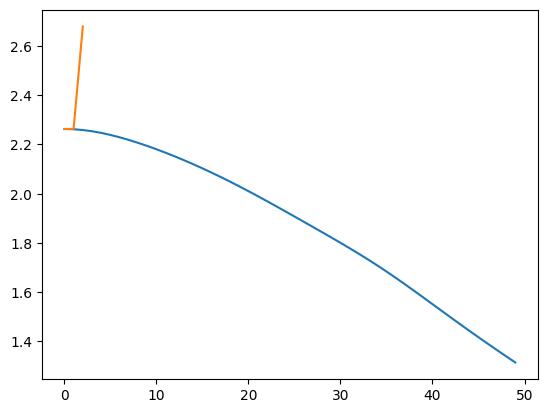

In [60]:
plt.plot(evs_obs_ex)

plt.plot(simulations[1]["evs"][:3])

In [32]:
simulations[1]["evs"][5]

(-1.14313188684449e+25+0j)

In [33]:
evs_obs_ex[5]

2.2388350786623072